Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Importing OpenRocket Dataset

In [2]:
CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR.parents[2]

ROCKET_DIR = PROJECT_ROOT / "01_rocket_sizing"

CSV_FILE = ROCKET_DIR / "release_states_data_clean.csv"

if not CSV_FILE.exists():
    raise FileNotFoundError(f"Cleaned dataset not found:\n{CSV_FILE}")

rocket_df = pd.read_csv(CSV_FILE)

print("=" * 70)
print("OPENROCKET DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print(f"\nFile: {CSV_FILE.name}")
print(f"Dataset shape: {rocket_df.shape[0]} rows × {rocket_df.shape[1]} columns")

display(rocket_df.head())

OPENROCKET DATASET LOADED SUCCESSFULLY

File: release_states_data_clean.csv
Dataset shape: 1059 rows × 58 columns


,Time (s),Altitude (m),Altitude above sea level (m),Vertical velocity (m/s),Total velocity (m/s),Vertical acceleration (m/s²),Total acceleration (m/s²),Position East of launch (m),Position North of launch (m),Lateral distance (m),...,Air pressure (mbar),Air density (g/cm³),Speed of sound (m/s),Mach number (​),Reynolds number (​),Reference length (cm),Reference area (cm²),Simulation time step (s),Computation time (s),Coriolis acceleration (m/s²)
0,0.000,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000000,0.0,0.000000,...,1013.250,0.001,340.389,0.007,199900.0,10,78.54,0.010,0.002,0.000000
1,0.010,0.000039,0.000039,0.028,0.028,12.147,12.147,-0.000003,0.0,0.000003,...,1013.250,0.001,340.389,0.007,199100.0,10,78.54,0.010,0.003,0.000004
2,0.020,0.001000,0.001000,0.259,0.259,34.094,34.095,-0.000014,0.0,0.000014,...,1013.250,0.001,340.389,0.007,199600.0,10,78.54,0.011,0.003,0.000033
3,0.031,0.007000,0.007000,0.767,0.767,58.247,58.247,-0.000035,0.0,0.000035,...,1013.249,0.001,340.389,0.007,208200.0,10,78.54,0.010,0.004,0.000098
4,0.041,0.017000,0.017000,1.361,1.361,60.466,60.466,-0.000064,0.0,0.000064,...,1013.248,0.001,340.389,0.008,228700.0,10,78.54,0.010,0.004,0.000174


Defining Mission target and extracting release states from Dataset

In [3]:
xT = 4000.0
yT = 3000.0
zT = 0.0

release_idx = rocket_df["Altitude (m)"].idxmax()

release_row = rocket_df.loc[release_idx]

x0 = release_row["Position East of launch (m)"]
y0 = release_row["Position North of launch (m)"]
z0 = release_row["Altitude (m)"]

t0 = release_row["Time (s)"]

azimuth_or = release_row["Lateral orientation (azimuth) (°)"]

print("=" * 70)
print("V1 MISSION INITIAL CONDITIONS")
print("=" * 70)

print("\nTarget Position:")
print(f"X = {xT:.2f} m")
print(f"Y = {yT:.2f} m")
print(f"Z = {zT:.2f} m")

print("\nPGV Release State:")
print(f"Release time = {t0:.2f} s")
print(f"X0 = {x0:.2f} m")
print(f"Y0 = {y0:.2f} m")
print(f"Z0 = {z0:.2f} m")

print("\nOpenRocket Azimuth:")
print(f"{azimuth_or:.2f}°")

V1 MISSION INITIAL CONDITIONS

Target Position:
X = 4000.00 m
Y = 3000.00 m
Z = 0.00 m

PGV Release State:
Release time = 18.49 s
X0 = 223.01 m
Y0 = 0.14 m
Z0 = 1939.57 m

OpenRocket Azimuth:
89.94°


Converting OpenRocket Azimuth to Cartesian convention & Calculate Heading Error

In [4]:
psi0_deg = (90.0 - azimuth_or) % 360.0

dx_target = xT - x0
dy_target = yT - y0

lambda0_deg = np.degrees(np.arctan2(dy_target, dx_target)) % 360.0

heading_error_deg = ((lambda0_deg - psi0_deg + 180.0) % 360.0) - 180.0

target_range = np.sqrt(dx_target**2 + dy_target**2)

print("=" * 70)
print("INITIAL GUIDANCE GEOMETRY")
print("=" * 70)

print(f"\nInitial PGV Heading = {psi0_deg:.2f}°")
print(f"Initial Target Bearing = {lambda0_deg:.2f}°")
print(f"Initial Heading Error = {heading_error_deg:.2f}°")

print(f"\nEast displacement to target = {dx_target:.2f} m")
print(f"North displacement to target = {dy_target:.2f} m")
print(f"Horizontal range to target = {target_range:.2f} m")

INITIAL GUIDANCE GEOMETRY

Initial PGV Heading = 0.06°
Initial Target Bearing = 38.46°
Initial Heading Error = 38.39°

East displacement to target = 3776.99 m
North displacement to target = 2999.86 m
Horizontal range to target = 4823.36 m


PGV Motion Model and Contraints

In [5]:
Vh = 6.2
Vz = -1.92

psi_dot_max_deg = 6.0
psi_dot_max = np.radians(psi_dot_max_deg)

dt = 0.1

flight_time = -z0 / Vz

print("=" * 70)
print("V1 MOTION AND GUIDANCE PARAMETERS")
print("=" * 70)

print(f"\nHorizontal speed, Vh = {Vh:.2f} m/s")
print(f"Vertical velocity, Vz = {Vz:.2f} m/s")
print(f"Maximum turn rate = {psi_dot_max_deg:.2f} deg/s")
print(f"Simulation time step, dt = {dt:.2f} s")

print(f"\nAvailable flight time = {flight_time:.2f} s")

turn_time_estimate = abs(heading_error_deg) / psi_dot_max_deg

print(f"Estimated initial heading correction time = {turn_time_estimate:.2f} s")

V1 MOTION AND GUIDANCE PARAMETERS

Horizontal speed, Vh = 6.20 m/s
Vertical velocity, Vz = -1.92 m/s
Maximum turn rate = 6.00 deg/s
Simulation time step, dt = 0.10 s

Available flight time = 1010.19 s
Estimated initial heading correction time = 6.40 s


Guidance Logic — Continuously calculate the target line-of-sight, heading error, and a turn command limited by the maximum turn rate.

In [6]:
def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def guidance_command(x, y, psi):
    dx = xT - x
    dy = yT - y

    lambda_angle = np.arctan2(dy, dx)

    heading_error = wrap_angle(lambda_angle - psi)

    psi_dot_cmd = np.clip(
        heading_error / dt,
        -psi_dot_max,
        psi_dot_max
    )

    return lambda_angle, heading_error, psi_dot_cmd

Guided Simulation — Propagate the PGV state in three dimensions while continuously applying the rate-limited pursuit guidance law

In [7]:
t = [0.0]
x = [x0]
y = [y0]
z = [z0]

psi = [np.radians(psi0_deg)]

los = []
heading_error = []
turn_rate = []
range_to_target = []

target_tolerance = 10.0

while z[-1] > 0:

    current_x = x[-1]
    current_y = y[-1]
    current_z = z[-1]
    current_psi = psi[-1]

    current_range = np.sqrt(
        (xT - current_x) ** 2 +
        (yT - current_y) ** 2
    )

    lambda_angle, error, psi_dot_cmd = guidance_command(
        current_x,
        current_y,
        current_psi
    )

    los.append(lambda_angle)
    heading_error.append(error)
    turn_rate.append(psi_dot_cmd)
    range_to_target.append(current_range)

    if current_range <= target_tolerance:

        print("=" * 70)
        print("TARGET REACHED")
        print("=" * 70)
        print(f"Time to target = {t[-1]:.2f} s")
        print(f"Horizontal range error = {current_range:.2f} m")
        print(f"Altitude at target = {current_z:.2f} m")

        break

    new_psi = wrap_angle(
        current_psi + psi_dot_cmd * dt
    )

    new_x = current_x + Vh * np.cos(new_psi) * dt
    new_y = current_y + Vh * np.sin(new_psi) * dt
    new_z = current_z + Vz * dt

    t.append(t[-1] + dt)
    x.append(new_x)
    y.append(new_y)
    z.append(new_z)
    psi.append(new_psi)

else:

    print("=" * 70)
    print("GROUND REACHED BEFORE TARGET")
    print("=" * 70)

    final_range = np.sqrt(
        (xT - x[-1]) ** 2 +
        (yT - y[-1]) ** 2
    )

    print(f"Final horizontal miss distance = {final_range:.2f} m")

t = np.array(t)
x = np.array(x)
y = np.array(y)
z = np.array(z)
psi = np.array(psi)

los = np.array(los)
heading_error = np.array(heading_error)
turn_rate = np.array(turn_rate)
range_to_target = np.array(range_to_target)

TARGET REACHED
Time to target = 776.90 s
Horizontal range error = 9.44 m
Altitude at target = 447.92 m


Evaluating the PGV arrival condition and the descent rate required to synchronize target arrival with ground contact.

In [8]:
final_time = t[-1]

final_x = x[-1]
final_y = y[-1]
final_z = z[-1]

final_range_error = np.sqrt(
    (xT - final_x) ** 2 +
    (yT - final_y) ** 2
)

Vz_required = -z0 / final_time

print("=" * 70)
print("V1 TERMINAL ARRIVAL ANALYSIS")
print("=" * 70)

print(f"\nTime to target = {final_time:.2f} s")

print(f"\nFinal Position:")
print(f"X = {final_x:.2f} m")
print(f"Y = {final_y:.2f} m")
print(f"Z = {final_z:.2f} m")

print(f"\nHorizontal range error = {final_range_error:.2f} m")

print(f"\nCurrent vertical velocity, Vz = {Vz:.2f} m/s")
print(f"Required average vertical velocity = {Vz_required:.2f} m/s")

print(f"\nRemaining altitude at target = {final_z:.2f} m")

print("=" * 70)

V1 TERMINAL ARRIVAL ANALYSIS

Time to target = 776.90 s

Final Position:
X = 3992.63 m
Y = 2994.11 m
Z = 447.92 m

Horizontal range error = 9.44 m

Current vertical velocity, Vz = -1.92 m/s
Required average vertical velocity = -2.50 m/s

Remaining altitude at target = 447.92 m


Horizontal Mission Geometry

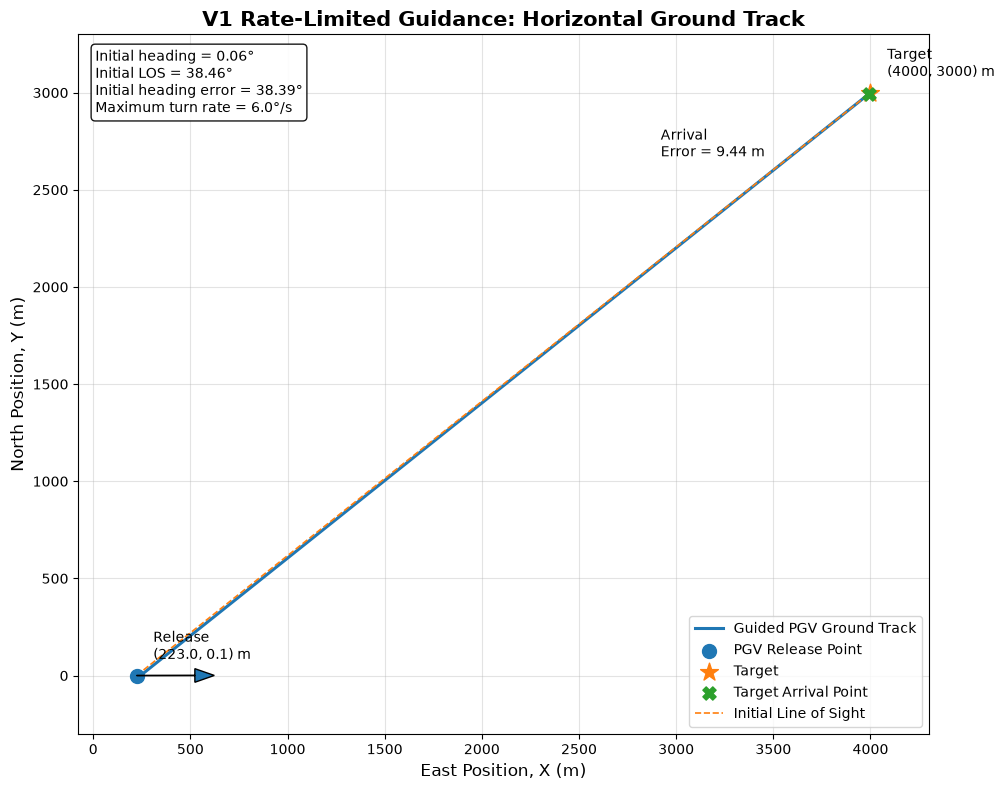

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    x,
    y,
    linewidth=2.2,
    label="Guided PGV Ground Track"
)

ax.scatter(
    x0,
    y0,
    s=100,
    marker="o",
    label="PGV Release Point",
    zorder=5
)

ax.scatter(
    xT,
    yT,
    s=180,
    marker="*",
    label="Target",
    zorder=6
)

ax.scatter(
    final_x,
    final_y,
    s=90,
    marker="X",
    label="Target Arrival Point",
    zorder=6
)

arrow_length = 400

ax.arrow(
    x0,
    y0,
    arrow_length * np.cos(np.radians(psi0_deg)),
    arrow_length * np.sin(np.radians(psi0_deg)),
    head_width=70,
    head_length=100,
    length_includes_head=True,
    zorder=5
)

ax.plot(
    [x0, xT],
    [y0, yT],
    linestyle="--",
    linewidth=1.2,
    label="Initial Line of Sight"
)

ax.annotate(
    f"Release\n({x0:.1f}, {y0:.1f}) m",
    xy=(x0, y0),
    xytext=(12, 12),
    textcoords="offset points"
)

ax.annotate(
    f"Target\n({xT:.0f}, {yT:.0f}) m",
    xy=(xT, yT),
    xytext=(12, 12),
    textcoords="offset points"
)

ax.annotate(
    f"Arrival\nError = {final_range_error:.2f} m",
    xy=(final_x, final_y),
    xytext=(-150, -45),
    textcoords="offset points"
)

ax.set_title(
    "V1 Rate-Limited Guidance: Horizontal Ground Track",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("East Position, X (m)", fontsize=12)
ax.set_ylabel("North Position, Y (m)", fontsize=12)

ax.grid(True, alpha=0.35)

ax.set_aspect("equal", adjustable="box")

x_margin = 300
y_margin = 300

ax.set_xlim(
    min(x0, xT, final_x) - x_margin,
    max(x0, xT, final_x) + x_margin
)

ax.set_ylim(
    min(y0, yT, final_y) - y_margin,
    max(y0, yT, final_y) + y_margin
)

ax.legend(
    loc="best",
    fontsize=10,
    frameon=True
)

ax.text(
    0.02,
    0.98,
    f"Initial heading = {psi0_deg:.2f}°\n"
    f"Initial LOS = {lambda0_deg:.2f}°\n"
    f"Initial heading error = {heading_error_deg:.2f}°\n"
    f"Maximum turn rate = {psi_dot_max_deg:.1f}°/s",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

Scaled down Graph where PGV achieved the turn

C:\Users\kaushik_jrparam\AppData\Local\Temp\ipykernel_13784\195852741.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


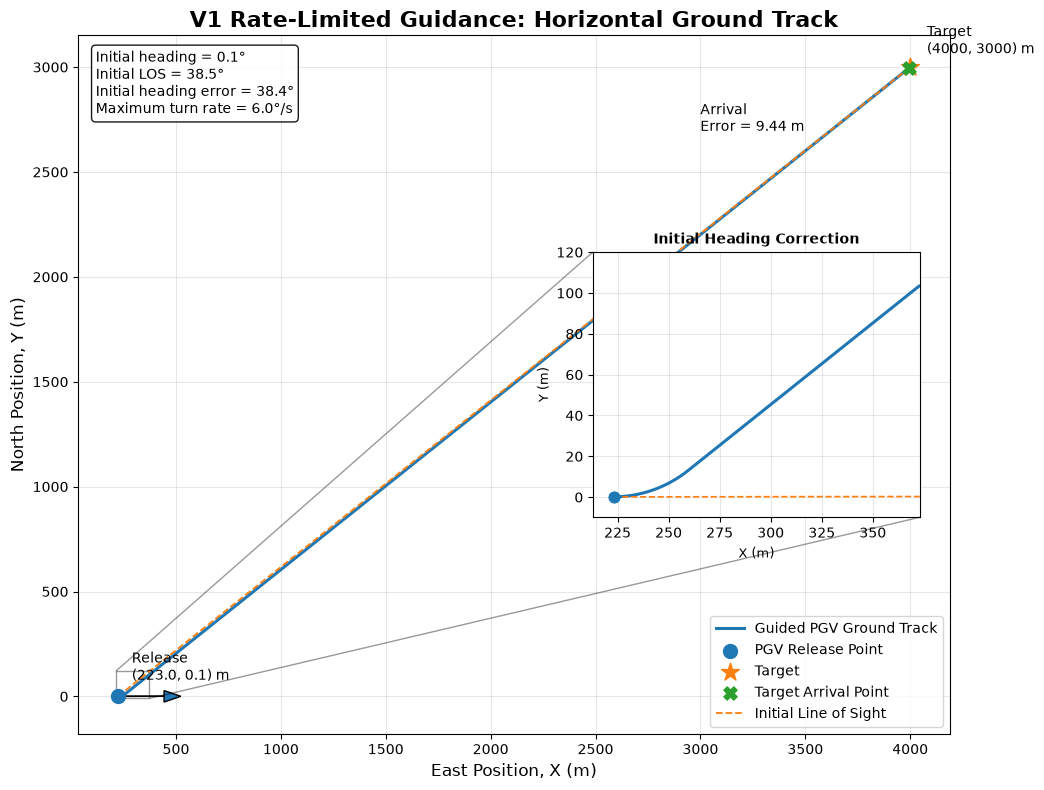

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(11, 8))

ax.plot(
    x,
    y,
    linewidth=2.2,
    label="Guided PGV Ground Track"
)

ax.scatter(
    x0,
    y0,
    s=100,
    marker="o",
    label="PGV Release Point",
    zorder=6
)

ax.scatter(
    xT,
    yT,
    s=180,
    marker="*",
    label="Target",
    zorder=7
)

ax.scatter(
    final_x,
    final_y,
    s=90,
    marker="X",
    label="Target Arrival Point",
    zorder=7
)

arrow_length = 300

ax.arrow(
    x0,
    y0,
    arrow_length * np.cos(np.radians(psi0_deg)),
    arrow_length * np.sin(np.radians(psi0_deg)),
    head_width=55,
    head_length=80,
    length_includes_head=True,
    zorder=5
)

ax.plot(
    [x0, xT],
    [y0, yT],
    linestyle="--",
    linewidth=1.3,
    label="Initial Line of Sight"
)

ax.annotate(
    f"Release\n({x0:.1f}, {y0:.1f}) m",
    xy=(x0, y0),
    xytext=(10, 12),
    textcoords="offset points"
)

ax.annotate(
    f"Target\n({xT:.0f}, {yT:.0f}) m",
    xy=(xT, yT),
    xytext=(12, 10),
    textcoords="offset points"
)

ax.annotate(
    f"Arrival\nError = {final_range_error:.2f} m",
    xy=(final_x, final_y),
    xytext=(-150, -45),
    textcoords="offset points"
)

ax.set_title(
    "V1 Rate-Limited Guidance: Horizontal Ground Track",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("East Position, X (m)", fontsize=12)
ax.set_ylabel("North Position, Y (m)", fontsize=12)

ax.grid(True, alpha=0.3)

ax.set_aspect("equal", adjustable="box")

ax.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

ax.text(
    0.02,
    0.98,
    f"Initial heading = {psi0_deg:.1f}°\n"
    f"Initial LOS = {lambda0_deg:.1f}°\n"
    f"Initial heading error = {heading_error_deg:.1f}°\n"
    f"Maximum turn rate = {psi_dot_max_deg:.1f}°/s",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc="center right",
    borderpad=2
)

zoom_distance = 150

zoom_mask = (
    (x >= x0 - 10) &
    (x <= x0 + zoom_distance)
)

axins.plot(
    x[zoom_mask],
    y[zoom_mask],
    linewidth=2.2
)

axins.scatter(
    x0,
    y0,
    s=60,
    marker="o",
    zorder=6
)

axins.plot(
    [x0, x0 + zoom_distance * np.cos(np.radians(psi0_deg))],
    [y0, y0 + zoom_distance * np.sin(np.radians(psi0_deg))],
    linestyle="--",
    linewidth=1.2
)

axins.set_xlim(x0 - 10, x0 + zoom_distance)
axins.set_ylim(y0 - 10, y0 + 120)

axins.set_title(
    "Initial Heading Correction",
    fontsize=10,
    fontweight="bold"
)

axins.set_xlabel("X (m)", fontsize=9)
axins.set_ylabel("Y (m)", fontsize=9)

axins.grid(True, alpha=0.3)
axins.set_aspect("equal", adjustable="box")

mark_inset(
    ax,
    axins,
    loc1=2,
    loc2=4,
    alpha=0.4
)

plt.tight_layout()
plt.show()

Initial Heading Correction

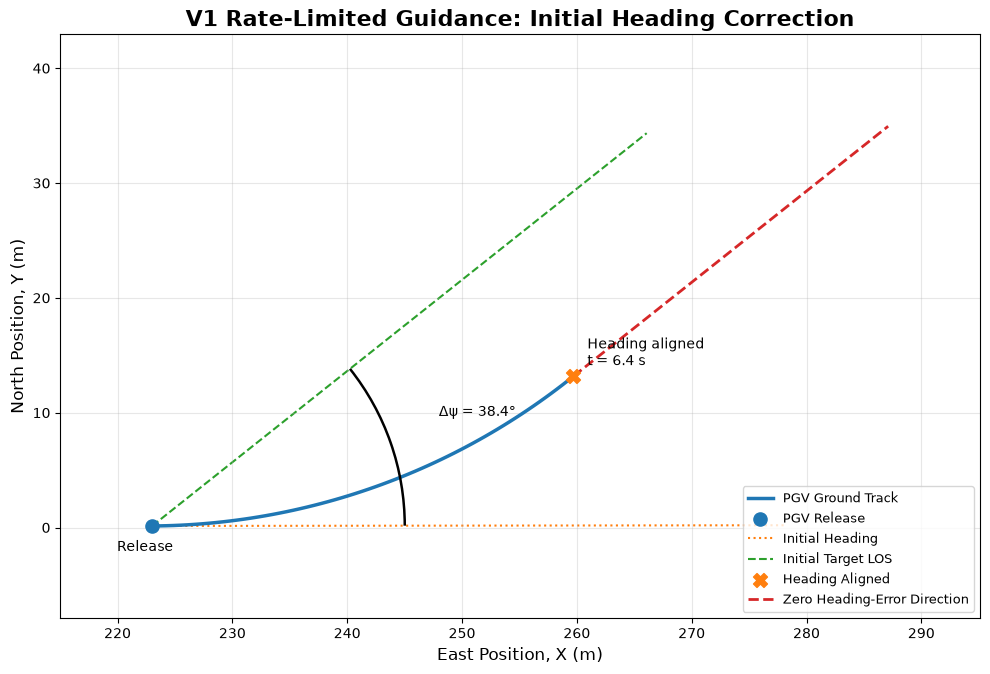

In [11]:
from matplotlib.patches import Arc

t_corr = abs(heading_error_deg) / psi_dot_max_deg

i_end = np.searchsorted(t, t_corr)
i_end = min(i_end, len(t) - 1)

xc = x[:i_end + 1]
yc = y[:i_end + 1]

x_end = x[i_end]
y_end = y[i_end]

psi_final = psi[i_end]

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    xc,
    yc,
    linewidth=2.5,
    label="PGV Ground Track",
    zorder=3
)

ax.scatter(
    x0,
    y0,
    s=90,
    marker="o",
    label="PGV Release",
    zorder=6
)

ax.annotate(
    "Release",
    xy=(x0, y0),
    xytext=(-5, -18),
    textcoords="offset points",
    ha="center",
    fontsize=10
)

ref_len = 55

x_hdg = x0 + ref_len * np.cos(np.radians(psi0_deg))
y_hdg = y0 + ref_len * np.sin(np.radians(psi0_deg))

ax.plot(
    [x0, x_hdg],
    [y0, y_hdg],
    linestyle=":",
    linewidth=1.5,
    label="Initial Heading",
    zorder=1
)

x_los = x0 + ref_len * np.cos(np.radians(lambda0_deg))
y_los = y0 + ref_len * np.sin(np.radians(lambda0_deg))

ax.plot(
    [x0, x_los],
    [y0, y_los],
    linestyle="--",
    linewidth=1.5,
    label="Initial Target LOS",
    zorder=1
)

arc_radius = 22

arc = Arc(
    (x0, y0),
    2 * arc_radius,
    2 * arc_radius,
    angle=0,
    theta1=min(psi0_deg, lambda0_deg),
    theta2=max(psi0_deg, lambda0_deg),
    linewidth=1.8,
    zorder=4
)

ax.add_patch(arc)

mid_angle = np.radians((psi0_deg + lambda0_deg) / 2)
text_radius = arc_radius + 8

ax.text(
    x0 + text_radius * np.cos(mid_angle),
    y0 + text_radius * np.sin(mid_angle),
    f"Δψ = {abs(heading_error_deg):.1f}°",
    fontsize=10,
    ha="center",
    va="center"
)

ax.scatter(
    x_end,
    y_end,
    s=100,
    marker="X",
    label="Heading Aligned",
    zorder=7
)

ax.annotate(
    f"Heading aligned\nt = {t[i_end]:.1f} s",
    xy=(x_end, y_end),
    xytext=(10, 8),
    textcoords="offset points",
    fontsize=10
)

extrap_len = 35

x_ext = x_end + extrap_len * np.cos(psi_final)
y_ext = y_end + extrap_len * np.sin(psi_final)

ax.plot(
    [x_end, x_ext],
    [y_end, y_ext],
    linestyle="--",
    linewidth=2,
    label="Zero Heading-Error Direction",
    zorder=2
)

margin = 8

ax.set_xlim(
    min(xc) - margin,
    max(x_ext, max(xc)) + margin
)

ax.set_ylim(
    min(yc) - margin,
    max(y_ext, max(yc)) + margin
)

ax.set_aspect("equal", adjustable="box")

ax.set_title(
    "V1 Rate-Limited Guidance: Initial Heading Correction",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("East Position, X (m)", fontsize=12)
ax.set_ylabel("North Position, Y (m)", fontsize=12)

ax.grid(True, alpha=0.3)

ax.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

Heading vs Time plot

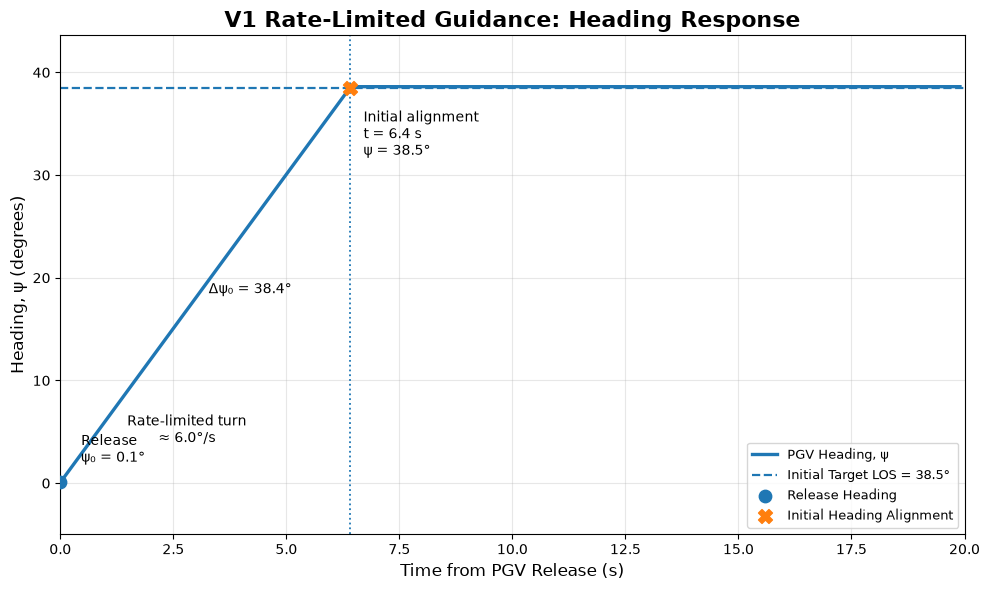

In [12]:
psi_deg = np.degrees(psi) % 360

t_plot_end = min(20.0, t[-1])

mask = t <= t_plot_end

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    t[mask],
    psi_deg[mask],
    linewidth=2.4,
    label="PGV Heading, ψ"
)

ax.axhline(
    lambda0_deg,
    linestyle="--",
    linewidth=1.6,
    label=f"Initial Target LOS = {lambda0_deg:.1f}°"
)

ax.scatter(
    t[0],
    psi_deg[0],
    s=80,
    label="Release Heading",
    zorder=6
)

ax.annotate(
    f"Release\nψ₀ = {psi0_deg:.1f}°",
    xy=(t[0], psi_deg[0]),
    xytext=(15, 15),
    textcoords="offset points",
    fontsize=10
)

ax.scatter(
    t[i_end],
    psi_deg[i_end],
    s=100,
    marker="X",
    label="Initial Heading Alignment",
    zorder=7
)

ax.axvline(
    t[i_end],
    linestyle=":",
    linewidth=1.3
)

ax.annotate(
    f"Initial alignment\n"
    f"t = {t[i_end]:.1f} s\n"
    f"ψ = {psi_deg[i_end]:.1f}°",
    xy=(t[i_end], psi_deg[i_end]),
    xytext=(10, -48),
    textcoords="offset points",
    fontsize=10
)

ax.text(
    2.8,
    4.0,
    f"Rate-limited turn\n≈ {psi_dot_max_deg:.1f}°/s",
    ha="center",
    fontsize=10
)

ax.text(
    4.2,
    18.5,
    f"Δψ₀ = {abs(heading_error_deg):.1f}°",
    ha="center",
    fontsize=10
)

ax.set_title(
    "V1 Rate-Limited Guidance: Heading Response",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Time from PGV Release (s)", fontsize=12)
ax.set_ylabel("Heading, ψ (degrees)", fontsize=12)

ax.set_xlim(0, t_plot_end)

ax.set_ylim(
    min(psi_deg[mask].min(), psi0_deg, lambda0_deg) - 5,
    max(psi_deg[mask].max(), psi0_deg, lambda0_deg) + 5
)

ax.grid(True, alpha=0.3)

ax.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

3D Mission Geomtry

V1 HEADING CORRECTION COMPLETION STATE

Correction completion time = 6.399 s

Position at heading alignment:
X = 259.766 m
Y = 12.979 m
Z = 1927.285 m

Altitude at correction completion = 1927.285 m

Final heading = 38.458°
Desired heading = 38.458°
Final heading error = 0.000000°

Horizontal distance travelled during correction = 38.935 m
Altitude lost during correction = 12.286 m


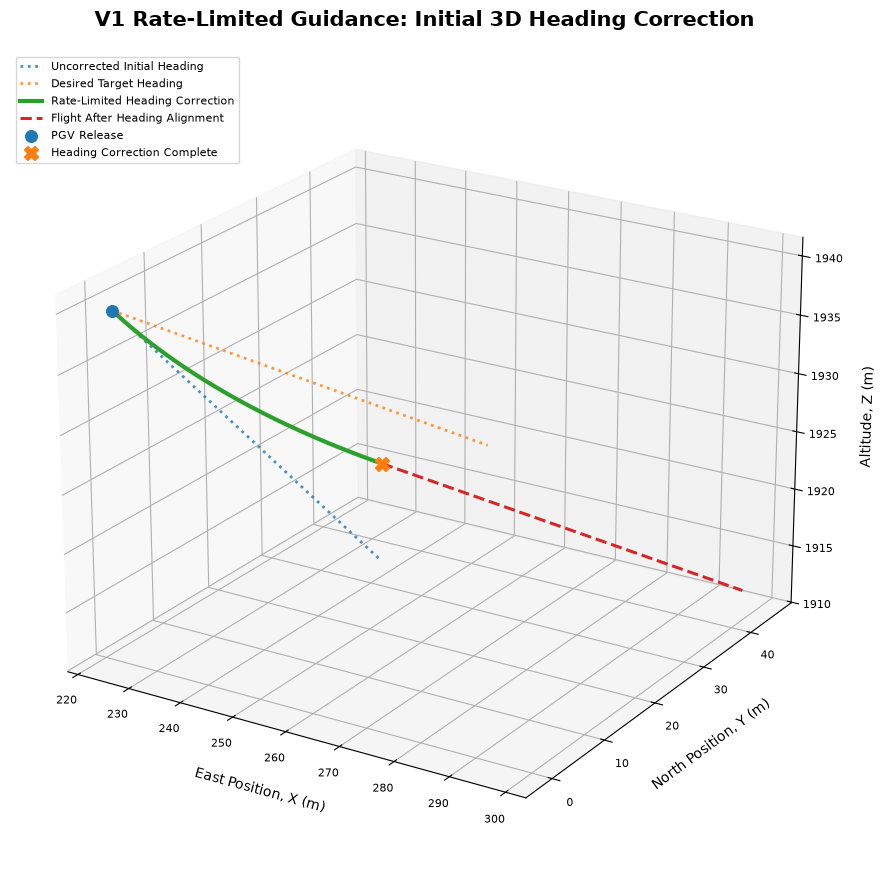

In [13]:
psi0 = np.radians(psi0_deg)
psi_desired = psi0 + np.radians(heading_error_deg)

psi_dot_max = np.radians(psi_dot_max_deg)
turn_sign = np.sign(heading_error_deg)

omega = turn_sign * psi_dot_max
t_align = abs(np.radians(heading_error_deg)) / psi_dot_max

t_turn = np.linspace(0.0, t_align, 200)

psi_turn = psi0 + omega * t_turn

x_turn = x0 + (Vh / omega) * (
    np.sin(psi_turn) - np.sin(psi0)
)

y_turn = y0 - (Vh / omega) * (
    np.cos(psi_turn) - np.cos(psi0)
)

z_turn = z0 + Vz * t_turn

x_align = x_turn[-1]
y_align = y_turn[-1]
z_align = z_turn[-1]

psi_align_deg = np.degrees(psi_desired) % 360.0

heading_error_final_deg = (
    (psi_align_deg - lambda0_deg + 180.0) % 360.0
) - 180.0

print("=" * 70)
print("V1 HEADING CORRECTION COMPLETION STATE")
print("=" * 70)

print(f"\nCorrection completion time = {t_align:.3f} s")

print("\nPosition at heading alignment:")
print(f"X = {x_align:.3f} m")
print(f"Y = {y_align:.3f} m")
print(f"Z = {z_align:.3f} m")

print(f"\nAltitude at correction completion = {z_align:.3f} m")

print(f"\nFinal heading = {psi_align_deg:.3f}°")
print(f"Desired heading = {lambda0_deg:.3f}°")
print(f"Final heading error = {heading_error_final_deg:.6f}°")

horizontal_distance_corrected = np.sqrt(
    (x_align - x0)**2 +
    (y_align - y0)**2
)

altitude_lost = z0 - z_align

print(f"\nHorizontal distance travelled during correction = "
      f"{horizontal_distance_corrected:.3f} m")

print(f"Altitude lost during correction = "
      f"{altitude_lost:.3f} m")

print("=" * 70)


display_time = 8.0

t_display = np.linspace(0.0, display_time, 100)

x_uncorrected = x0 + Vh * np.cos(psi0) * t_display
y_uncorrected = y0 + Vh * np.sin(psi0) * t_display
z_uncorrected = z0 + Vz * t_display

x_desired = x0 + Vh * np.cos(psi_desired) * t_display
y_desired = y0 + Vh * np.sin(psi_desired) * t_display
z_desired = z0 + Vz * t_display

t_after = np.linspace(0.0, display_time, 100)

x_after = x_align + Vh * np.cos(psi_desired) * t_after
y_after = y_align + Vh * np.sin(psi_desired) * t_after
z_after = z_align + Vz * t_after

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x_uncorrected,
    y_uncorrected,
    z_uncorrected,
    linestyle=":",
    linewidth=2.0,
    alpha=0.8,
    label="Uncorrected Initial Heading"
)

ax.plot(
    x_desired,
    y_desired,
    z_desired,
    linestyle=":",
    linewidth=2.0,
    alpha=0.8,
    label="Desired Target Heading"
)

ax.plot(
    x_turn,
    y_turn,
    z_turn,
    linewidth=3.0,
    label="Rate-Limited Heading Correction"
)

ax.plot(
    x_after,
    y_after,
    z_after,
    linestyle="--",
    linewidth=2.2,
    label="Flight After Heading Alignment"
)

ax.scatter(
    x0,
    y0,
    z0,
    s=70,
    marker="o",
    label="PGV Release"
)

ax.scatter(
    x_align,
    y_align,
    z_align,
    s=100,
    marker="X",
    label="Heading Correction Complete"
)

all_x = np.concatenate([
    x_uncorrected,
    x_desired,
    x_turn,
    x_after
])

all_y = np.concatenate([
    y_uncorrected,
    y_desired,
    y_turn,
    y_after
])

all_z = np.concatenate([
    z_uncorrected,
    z_desired,
    z_turn,
    z_after
])

x_margin = 5.0
y_margin = 5.0
z_margin = 2.0

ax.set_xlim(all_x.min() - x_margin, all_x.max() + x_margin)
ax.set_ylim(all_y.min() - y_margin, all_y.max() + y_margin)
ax.set_zlim(all_z.min() - z_margin, all_z.max() + z_margin)

ax.set_title(
    "V1 Rate-Limited Guidance: Initial 3D Heading Correction",
    fontsize=15,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("East Position, X (m)", fontsize=10, labelpad=10)
ax.set_ylabel("North Position, Y (m)", fontsize=10, labelpad=10)
ax.set_zlabel("Altitude, Z (m)", fontsize=10, labelpad=10)

ax.tick_params(labelsize=8)

ax.view_init(elev=22, azim=-58)

ax.legend(
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

Altitude vs Horizontal Distance

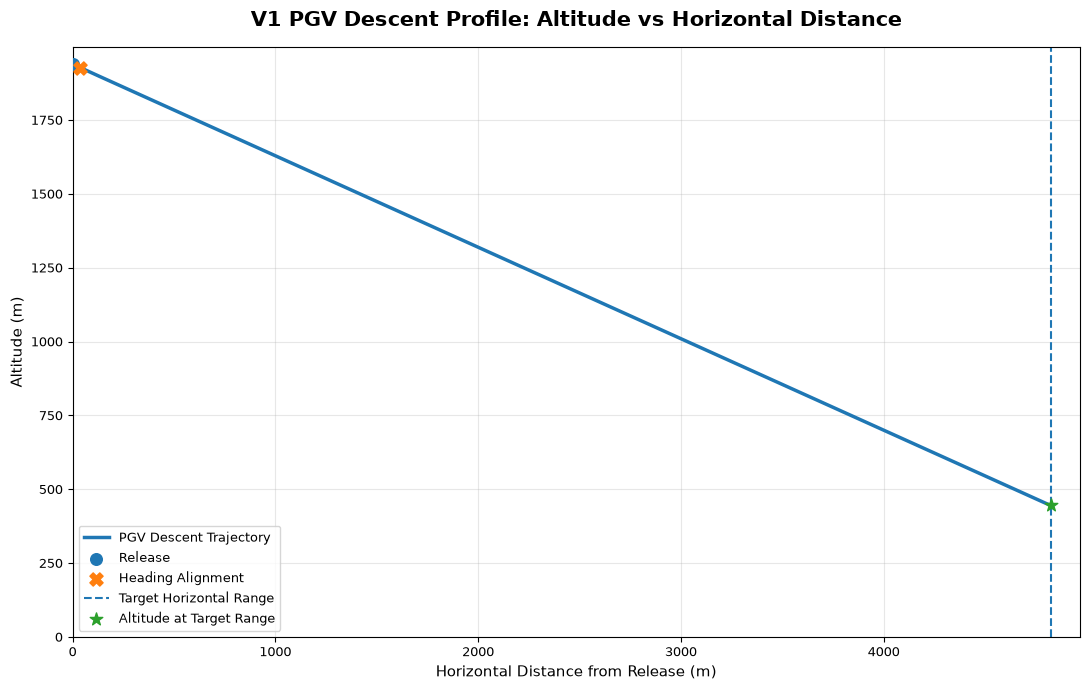

V1 ALTITUDE–RANGE ANALYSIS

Release altitude = 1939.57 m
Heading alignment altitude = 1927.28 m
Horizontal distance at alignment = 38.94 m

Target horizontal range = 4823.36 m
Predicted altitude at target range = 445.88 m


In [14]:
horizontal_distance = np.sqrt(
    (x - x0)**2 +
    (y - y0)**2
)

i_align = np.searchsorted(
    horizontal_distance,
    np.sqrt(
        (x_align - x0)**2 +
        (y_align - y0)**2
    )
)

target_horizontal_distance = np.sqrt(
    (xT - x0)**2 +
    (yT - y0)**2
)

target_altitude = z0 + Vz * (
    target_horizontal_distance / Vh
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    horizontal_distance,
    z,
    linewidth=2.5,
    label="PGV Descent Trajectory"
)

ax.scatter(
    0,
    z0,
    s=70,
    marker="o",
    label="Release",
    zorder=5
)

ax.scatter(
    horizontal_distance[i_align],
    z[i_align],
    s=90,
    marker="X",
    label="Heading Alignment",
    zorder=6
)

ax.axvline(
    target_horizontal_distance,
    linestyle="--",
    linewidth=1.5,
    label="Target Horizontal Range"
)

ax.scatter(
    target_horizontal_distance,
    target_altitude,
    s=90,
    marker="*",
    label="Altitude at Target Range",
    zorder=7
)

ax.set_title(
    "V1 PGV Descent Profile: Altitude vs Horizontal Distance",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Horizontal Distance from Release (m)",
    fontsize=11
)

ax.set_ylabel(
    "Altitude (m)",
    fontsize=11
)

ax.tick_params(labelsize=9)

ax.grid(True, alpha=0.3)

ax.legend(
    fontsize=9,
    loc="best",
    frameon=True
)

ax.set_xlim(
    0,
    max(horizontal_distance.max(), target_horizontal_distance) * 1.03
)

ax.set_ylim(
    0,
    z0 * 1.03
)

plt.tight_layout()
plt.show()

print("=" * 70)
print("V1 ALTITUDE–RANGE ANALYSIS")
print("=" * 70)

print(f"\nRelease altitude = {z0:.2f} m")

print(
    f"Heading alignment altitude = "
    f"{z[i_align]:.2f} m"
)

print(
    f"Horizontal distance at alignment = "
    f"{horizontal_distance[i_align]:.2f} m"
)

print(
    f"\nTarget horizontal range = "
    f"{target_horizontal_distance:.2f} m"
)

print(
    f"Predicted altitude at target range = "
    f"{target_altitude:.2f} m"
)

print("=" * 70)

Range-to-Target vs Time

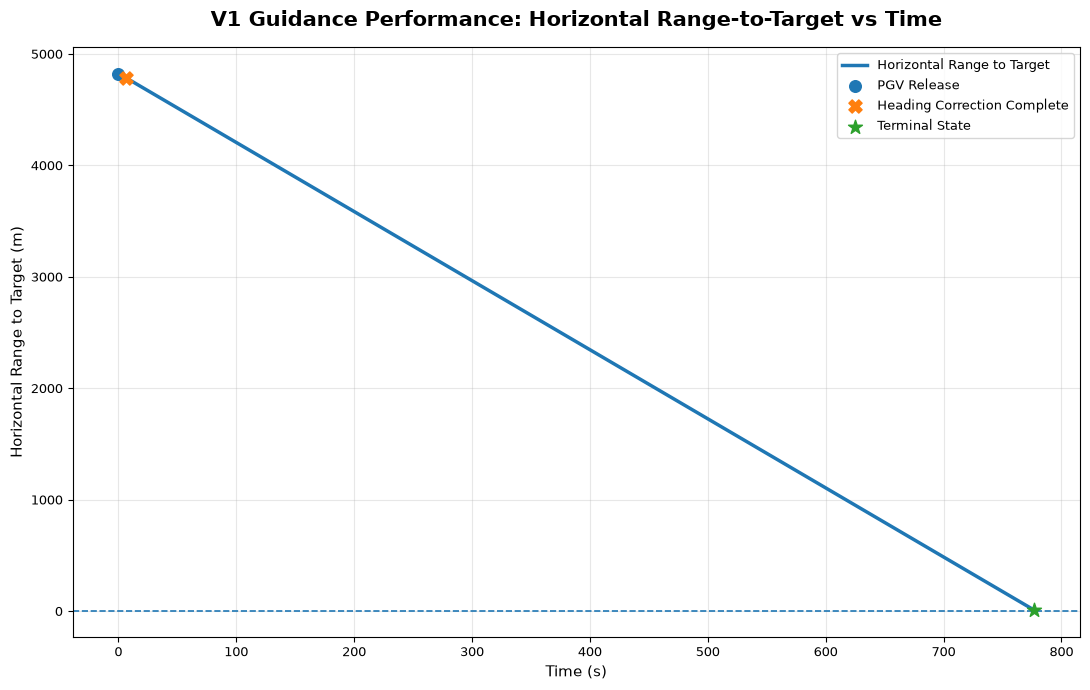

V1 RANGE CLOSURE ANALYSIS

Initial range to target = 4823.36 m
Range at heading alignment = 4786.54 m
Final range to target = 9.44 m

Heading correction completed at t = 6.400 s


In [15]:
range_to_target = np.sqrt(
    (xT - x)**2 +
    (yT - y)**2
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    t,
    range_to_target,
    linewidth=2.5,
    label="Horizontal Range to Target"
)

ax.scatter(
    t[0],
    range_to_target[0],
    s=70,
    marker="o",
    label="PGV Release",
    zorder=5
)

ax.scatter(
    t[i_end],
    range_to_target[i_end],
    s=90,
    marker="X",
    label="Heading Correction Complete",
    zorder=6
)

ax.scatter(
    t[-1],
    range_to_target[-1],
    s=110,
    marker="*",
    label="Terminal State",
    zorder=7
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_title(
    "V1 Guidance Performance: Horizontal Range-to-Target vs Time",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Horizontal Range to Target (m)", fontsize=11)

ax.tick_params(labelsize=9)

ax.grid(True, alpha=0.3)

ax.legend(
    fontsize=9,
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()

print("=" * 70)
print("V1 RANGE CLOSURE ANALYSIS")
print("=" * 70)

print(f"\nInitial range to target = {range_to_target[0]:.2f} m")
print(f"Range at heading alignment = {range_to_target[i_end]:.2f} m")
print(f"Final range to target = {range_to_target[-1]:.2f} m")

print(f"\nHeading correction completed at t = {t[i_end]:.3f} s")

print("=" * 70)